# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [2]:
# Membaca dataset earthquakes tahun 2023 dari kaggle dan menampilkan 5 baris pertama
df_cluster = pd.read_csv('hasil_clustering.csv')
df_cluster.head()

,latitude,longitude,depth,mag,nst,gap,rms,depthError,magType,net,type,status,locationSource,magSource,cluster
0,28.526166,-69.259223,85.157927,3.486614,39.102321,158.833298,0.496010,6.224992,ml,us,earthquake,reviewed,us,us,1
1,14.834924,39.864315,68.005842,4.153169,58.677624,112.623486,0.622875,4.306792,mb,us,earthquake,reviewed,us,us,0
2,29.245062,-116.196223,120.328526,3.260603,29.852577,176.047097,0.456821,7.319316,ml,us,earthquake,reviewed,us,us,1
3,15.285344,11.966053,88.786111,4.018562,53.183503,122.866876,0.599513,4.956029,mb,us,earthquake,reviewed,us,us,0
4,35.600594,-69.509295,47.335596,3.402408,40.187975,162.565967,0.474770,5.862589,ml,us,earthquake,reviewed,us,us,1


# **3. Data Splitting**

sebelumnya saya ingin menganalisis hasil dari dataset cluster terlebih dahulu

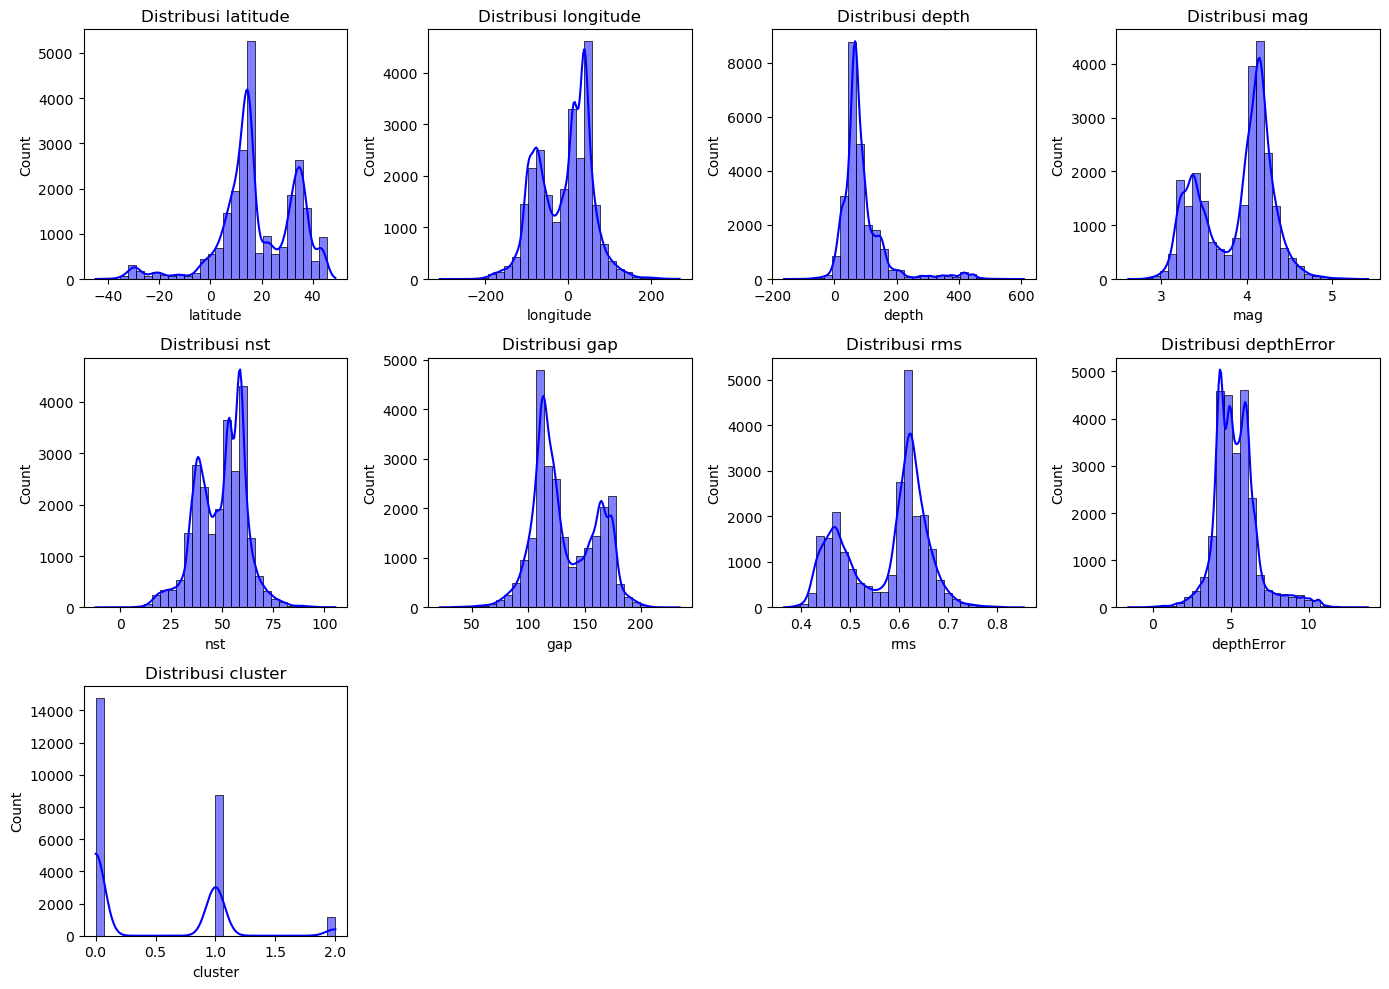

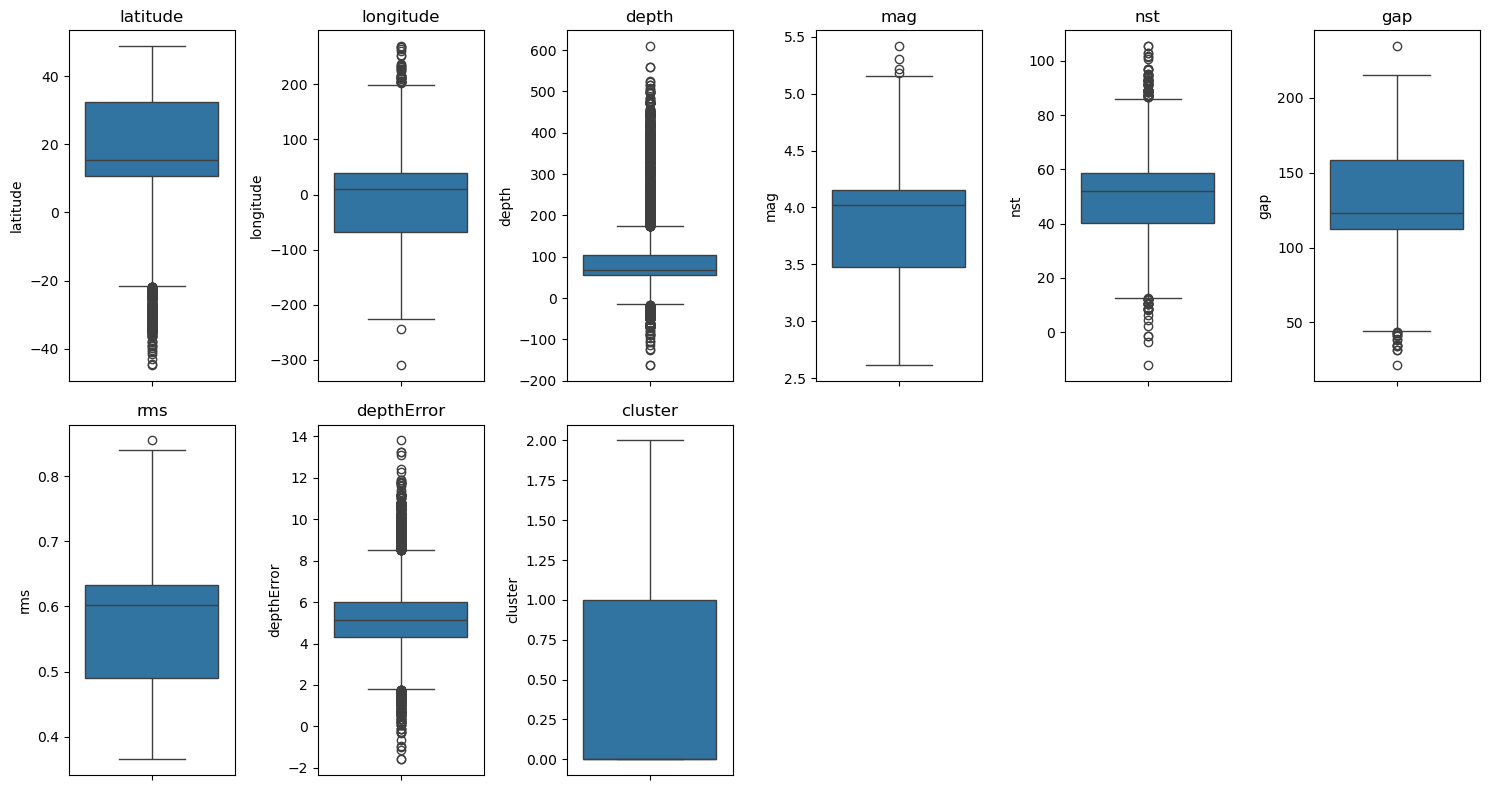

C:\Users\septi\AppData\Local\Temp\ipykernel_16456\3209157162.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cluster[column], palette='viridis')
C:\Users\septi\AppData\Local\Temp\ipykernel_16456\3209157162.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cluster[column], palette='viridis')
C:\Users\septi\AppData\Local\Temp\ipykernel_16456\3209157162.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_cluster[column], palette='viridis')
C:\Users\septi\AppData\Local\Temp\ipykernel_16456\3209157162.py:25: FutureWa

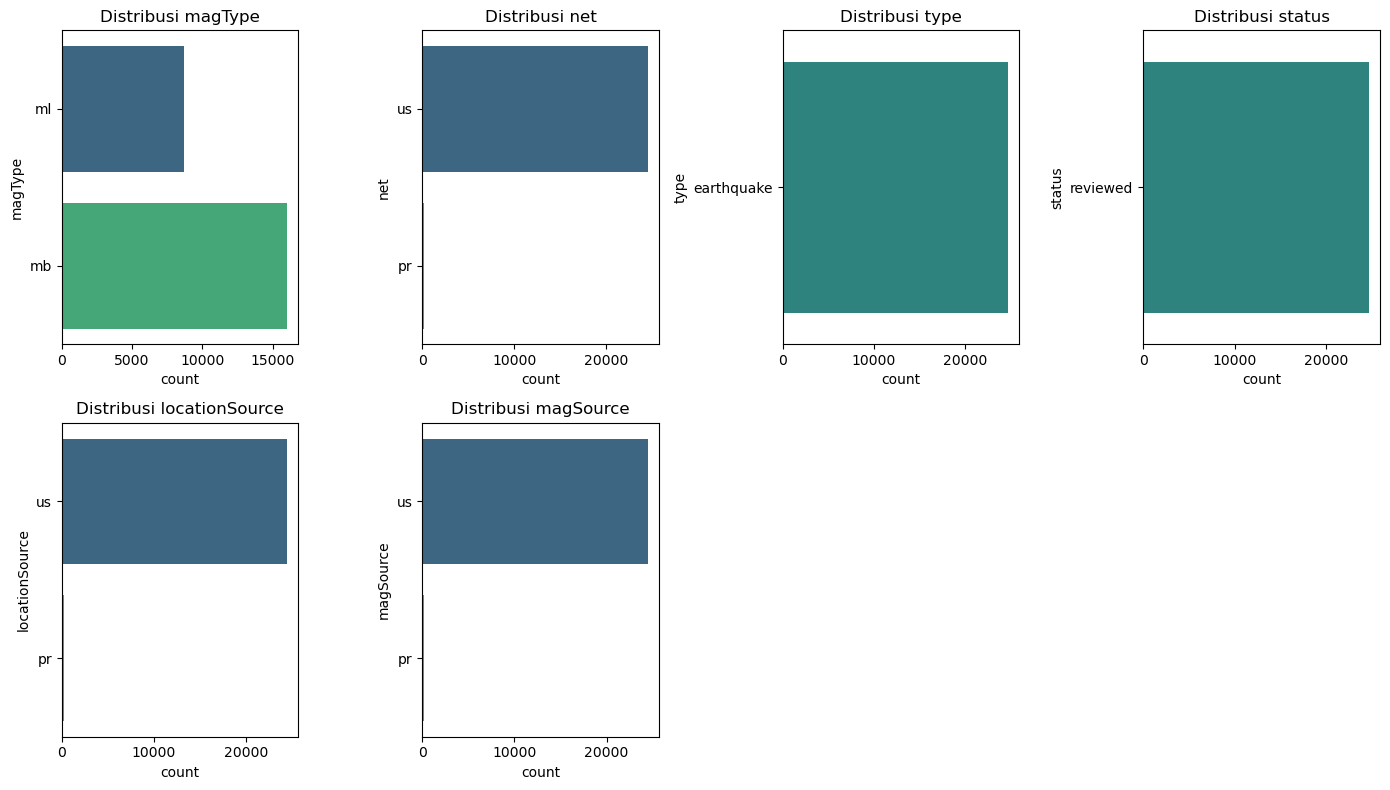

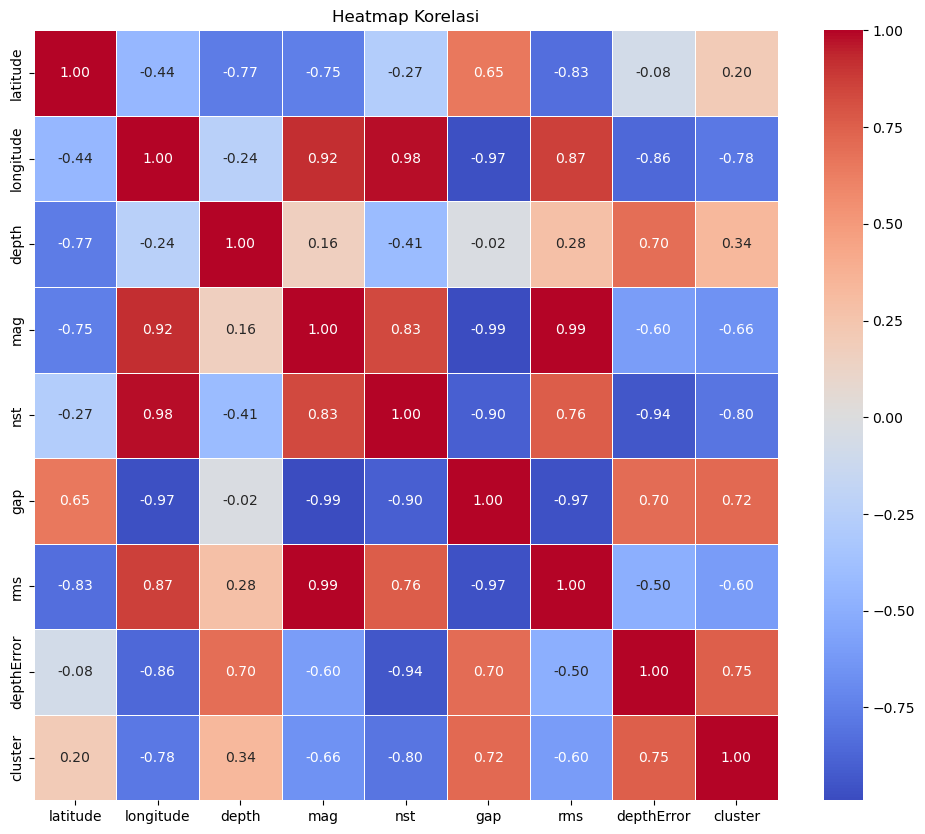

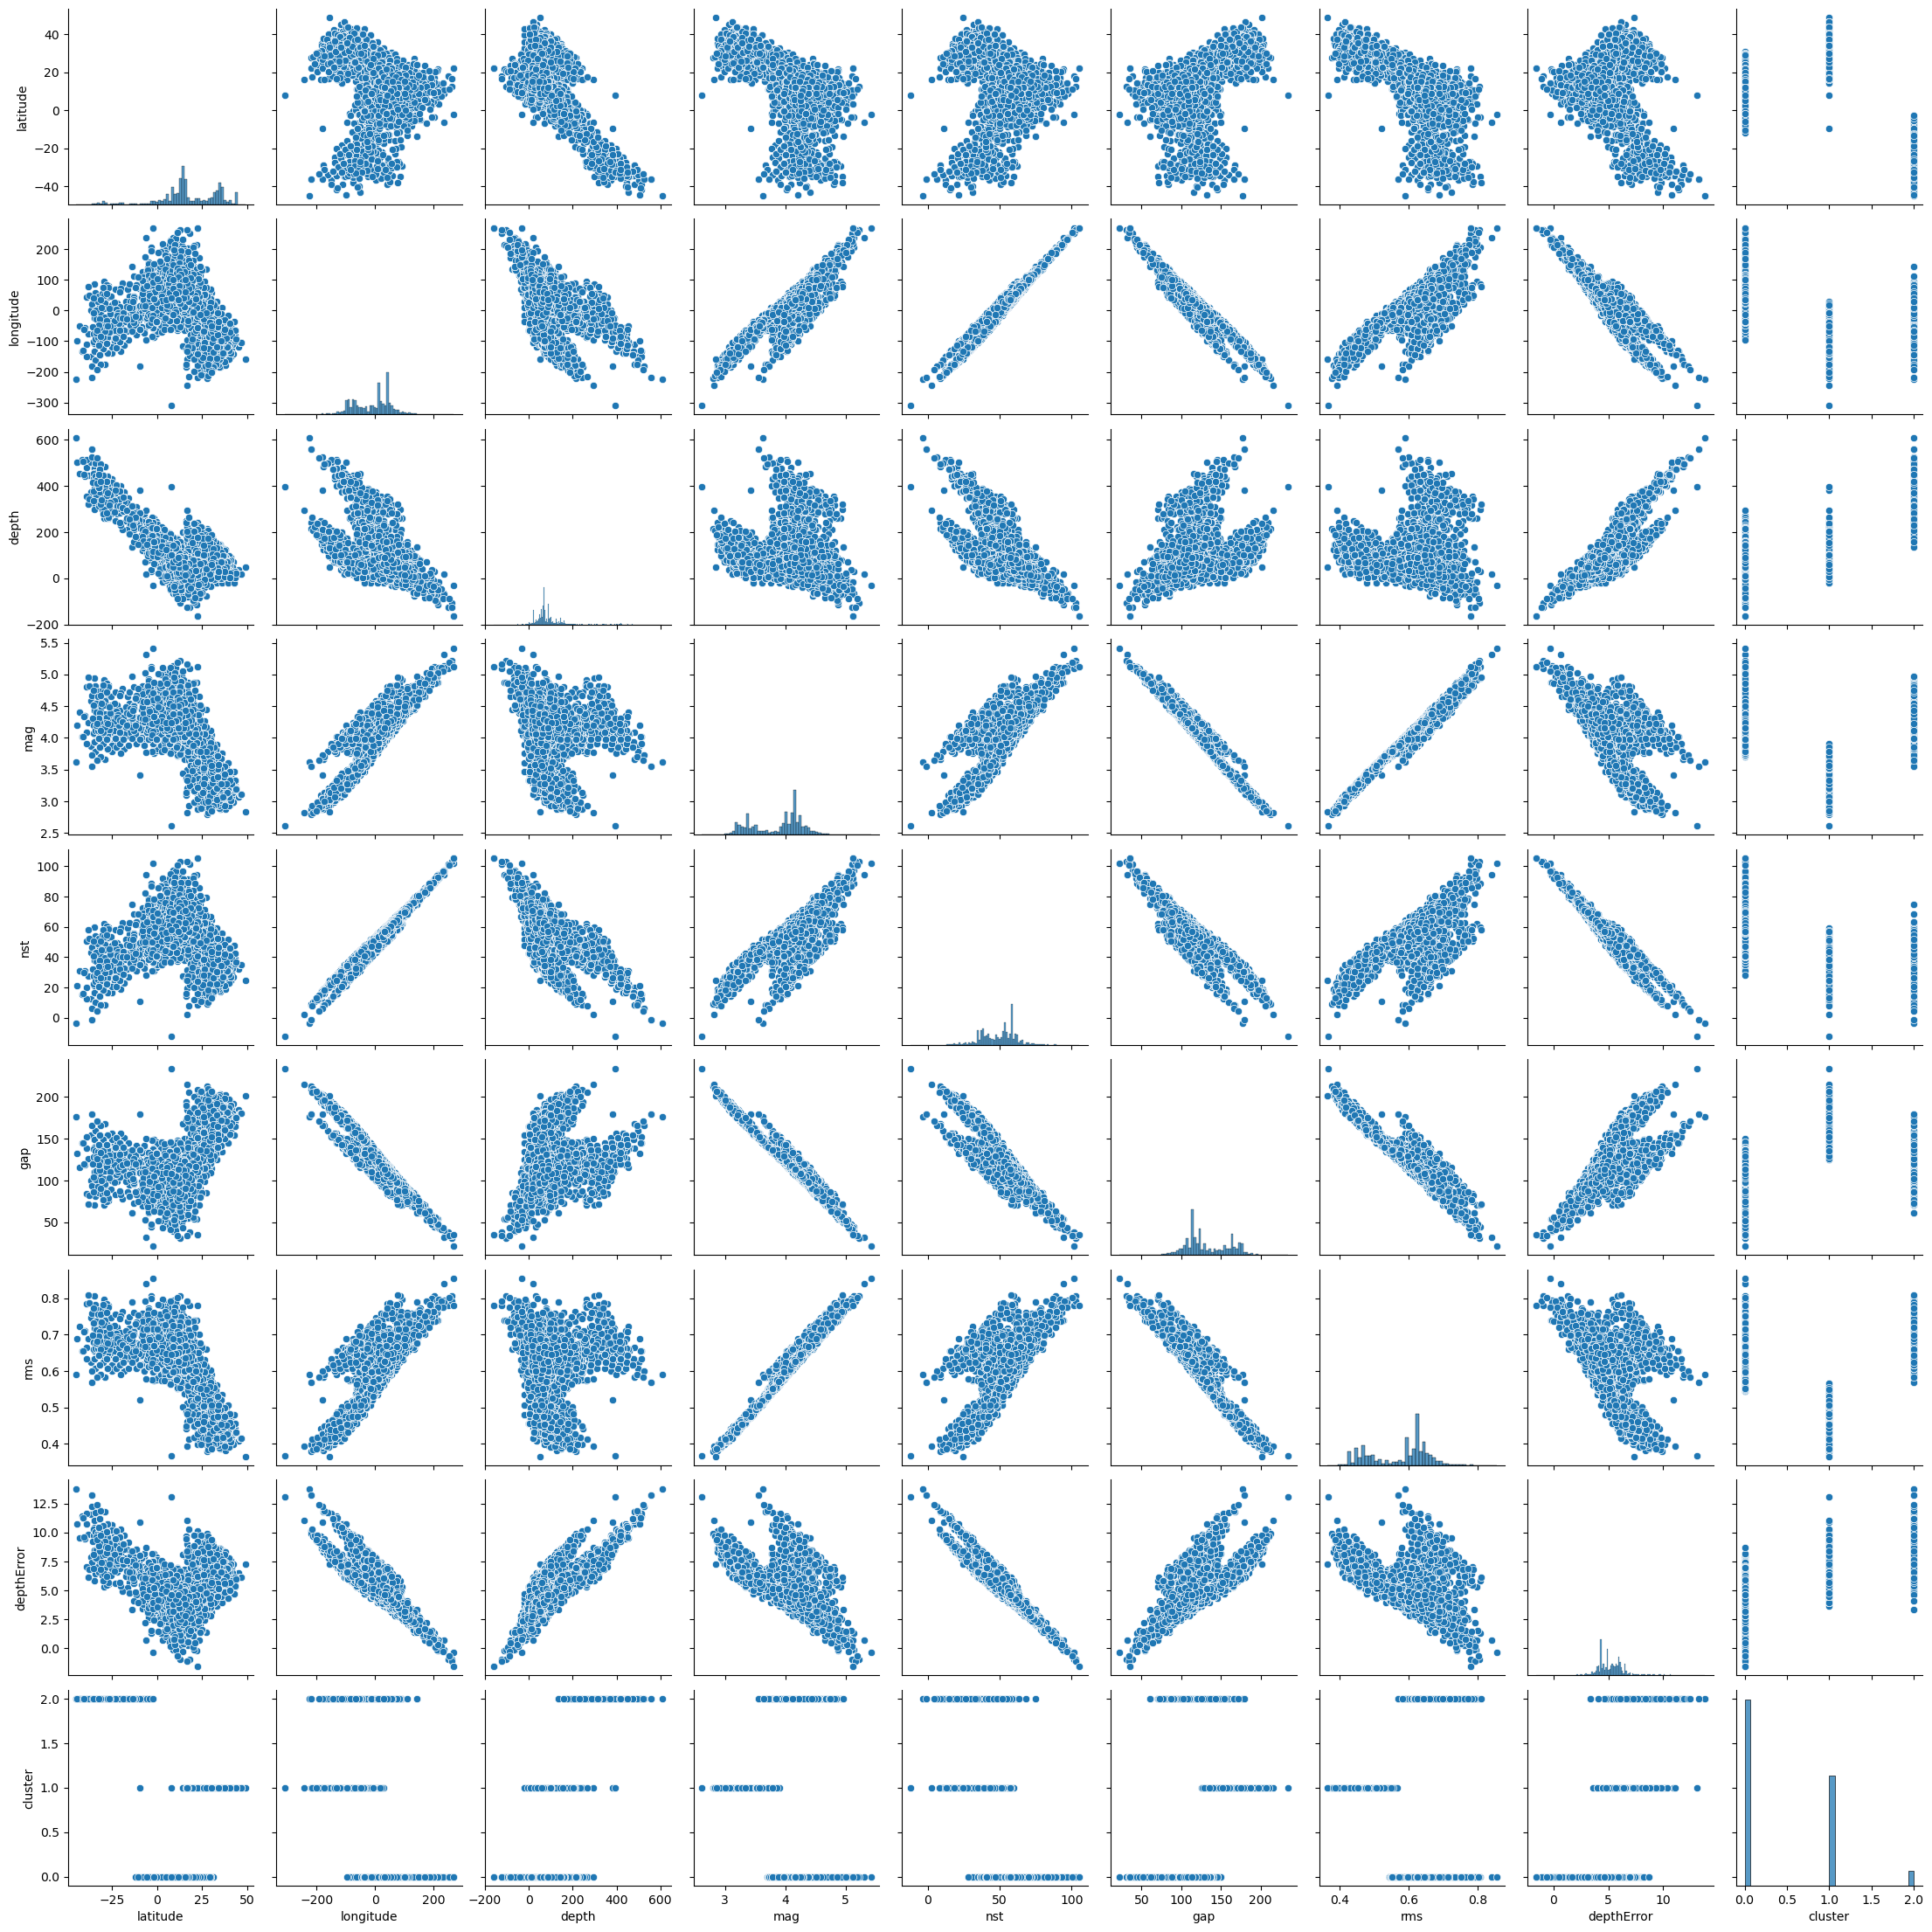

In [9]:
# Distribusi fitur numerik
num_features = df_cluster.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df_cluster[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# Mengidentifikasi outlier untuk fitur numerik
plt.figure(figsize=(15, 8))
for i, feature in enumerate(num_features, 1):
    plt.subplot(2, 6, i)
    sns.boxplot(y=df_cluster[feature]) 
    plt.title(feature) 
plt.tight_layout()
plt.show()

# Distribusi fitur kategorikal
cat_features = df_cluster.select_dtypes(include=[object])
plt.figure(figsize=(14, 8))
for i, column in enumerate(cat_features.columns, 1):
    plt.subplot(2, 4, i)
    sns.countplot(y=df_cluster[column], palette='viridis')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

# Pairplot untuk fitur numerik
sns.pairplot(num_features)
plt.show()

dari hasil analisis tersebut ada beberapa kolom yang perlu dihapus

In [11]:
# Hapus kolom 'RowNumber', 'CustomerId', dan 'Surname'
df = df_cluster.drop(columns=['type', # Hapus karena variancenya rendah
                            'status', # Hapus karena variancenya rendah
                            'locationSource', # Hapus karena variancenya sudah diwakilkan oleh fitur net
                            'magSource' # Hapus karena variancenya sudah diwakilkan oleh fitur net
                          ])

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [4]:
# Mengubah data kategorikal menjadi numerik menggunakan OneHotEncoder
cat_features = df_cluster.select_dtypes(include=['object']).columns

# Menggunakan pd.get_dummies untuk One-Hot Encoding 
df_encoded  = pd.get_dummies(df_cluster, columns=cat_features)

# Konversi boolean menjadi numerik (0 dan 1)
df_encoded = df_encoded.astype(int)

# Menampilkan hasil
df_encoded 

,latitude,longitude,depth,mag,nst,gap,rms,depthError,cluster,magType_mb,magType_ml,net_pr,net_us,type_earthquake,status_reviewed,locationSource_pr,locationSource_us,magSource_pr,magSource_us
0,28,-69,85,3,39,158,0,6,1,0,1,0,1,1,1,0,1,0,1
1,14,39,68,4,58,112,0,4,0,1,0,0,1,1,1,0,1,0,1
2,29,-116,120,3,29,176,0,7,1,0,1,0,1,1,1,0,1,0,1
3,15,11,88,4,53,122,0,4,0,1,0,0,1,1,1,0,1,0,1
4,35,-69,47,3,40,162,0,5,1,0,1,0,1,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24677,8,73,72,4,64,97,0,3,0,1,0,0,1,1,1,0,1,0,1
24678,11,61,67,4,62,103,0,3,0,1,0,0,1,1,1,0,1,0,1
24679,10,53,82,4,60,105,0,4,0,1,0,0,1,1,1,0,1,0,1
24680,8,41,103,4,57,108,0,4,0,1,0,0,1,1,1,0,1,0,1


In [5]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=['cluster'])
y = df_encoded['cluster']

# Split data menjadi set pelatihan dan set uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tampilkan bentuk set pelatihan dan set uji untuk memastikan split
print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set shape: X_train=(19745, 18), y_train=(19745,)
Test set shape: X_test=(4937, 18), y_test=(4937,)


# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [6]:
# Definisikan setiap klasifikasi secara terpisah
knn = KNeighborsClassifier().fit(X_train, y_train)
dt = DecisionTreeClassifier().fit(X_train, y_train)
rf = RandomForestClassifier().fit(X_train, y_train)
svm = SVC().fit(X_train, y_train)
nb = GaussianNB().fit(X_train, y_train)
 
print("Model training selesai.")

Model training selesai.


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

In [ ]:
# Fungsi untuk mengevaluasi dan mengembalikan hasil sebagai kamus
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    results = {
        'Confusion Matrix': cm,
        'True Positive (TP)': tp,
        'False Positive (FP)': fp,
        'False Negative (FN)': fn,
        'True Negative (TN)': tn,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    return results
 
# Mengevaluasi setiap model dan mengumpulkan hasilnya
results = {
    'K-Nearest Neighbors (KNN)': evaluate_model(knn, X_test, y_test),
    'Decision Tree (DT)': evaluate_model(dt, X_test, y_test),
    'Random Forest (RF)': evaluate_model(rf, X_test, y_test),
    'Support Vector Machine (SVM)': evaluate_model(svm, X_test, y_test),
    'Naive Bayes (NB)': evaluate_model(nb, X_test, y_test)
}
 
# Buat DataFrame untuk meringkas hasil
summary_df = pd.DataFrame.from_dict(
    {model_name: {
        'Accuracy': metrics['Accuracy'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1-Score': metrics['F1-Score']
    } for model_name, metrics in results.items()},
    orient='index'
).reset_index()

# Ubah nama kolom
summary_df.rename(columns={'index': 'Model'}, inplace=True)

# Tampilkan DataFrame
print(summary_df)

ValueError: too many values to unpack (expected 4)

Tulis hasil evaluasi algoritma yang digunakan, jika Anda menggunakan 2 algoritma, maka bandingkan hasilnya.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
#Type your code here

## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.

In [ ]:
#Type your code here

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Bandingkan hasil evaluasi sebelum dan setelah tuning (jika dilakukan).
2. Identifikasi kelemahan model, seperti:
  - Precision atau Recall rendah untuk kelas tertentu.
  - Apakah model mengalami overfitting atau underfitting?
3. Berikan rekomendasi tindakan lanjutan, seperti mengumpulkan data tambahan atau mencoba algoritma lain jika hasil belum memuaskan.